# Vocabulary

Lexical diversity metrics are used to measure the richness of vocabulary used in a text. The Zipfian distribution of word frequencies makes this harder to quantify than it might seem at first glance. Vocabulary size is highly dependent on text length, so the longer a text is the more its words repeat. A metric that looks like a description of a text's vocabulary often turns out to be a description of its size. Each measure below offers a partial solution to that problem.

1. **Type-token ratio** -- `ttr`, over a whole text and over a fixed window, which is where the length problem shows itself.
2. **Length-controlled measures** -- `msttr` and `mtld`, and how far the three of them agree.
3. **One word class at a time** -- the same measures over the nouns and the verbs alone, and what a shorter, more varied sequence does to them.
4. **Vocabulary growth curves** -- `vocabulary_growth`, which displays the dependence on length instead of correcting for it.
5. **The frequency spectrum** -- `frequency_spectrum`, the distribution all of these summarize.

The first three sections use the Brown corpus. For the remainder, we need longer text samples and use a selection of books.  For reference about the functions called here, see: [Lexical metrics API](../../lexical/).

**References**

- Baayen, R. H. 2001. *Word Frequency Distributions.* Kluwer Academic Publishers.
- Johnson, W. 1944. Studies in language behavior: A program of research. *Psychological Monographs* 56(2): 1-15.
- McCarthy, P. M. & Jarvis, S. 2010. MTLD, vocd-D, and HD-D: A validation study of sophisticated approaches to lexical diversity assessment. *Behavior Research Methods* 42(2): 381-392.
- Tweedie, F. J. & Baayen, R. H. 1998. How variable may a constant be? Measures of lexical richness in perspective. *Computers and the Humanities* 32(5): 323-352.

In [1]:
import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

pl.Config.set_float_precision(2)
pl.Config.set_tbl_rows(15)

polars.config.Config

## The corpus

These examples use the British National Corpus.

We normalize the text in the same way we did in [Word frequencies](../frequencies/): filtering using `plc.is_letters` keeps the tokens made of up letters, apostrophes and hyphens while dropping punctuation and numerals, and `str.to_lowercase` folds *The* in with *the*.

In [2]:
bnc = (
    pl.scan_parquet("../../data/bnc.parquet")
    .filter(plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
)

## Four measures at once

`group_by("file_id")` makes each text a group and `agg` returns one row per text, with `pl.col("text_type").first()` carrying the genre label through as constant. The measures are all expressions, so they compose with ordinary Polars:

- `plc.ttr("token")` is the type-token ratio $V/N$ over the whole text.
- `plc.ttr(pl.col("token").head(500))` is the same ratio over the first 500 tokens. Nothing special is needed to restrict the window: `ttr` takes an expression, and `head` is an expression.
- `plc.msttr("token", 500)` cuts the text into consecutive 500-token segments, takes each segment's TTR and averages them. The tail left over after the last complete segment is dropped, and any text sample shorter than a single segment comes back null.
- `plc.mtld("token")` reads through the text keeping a running TTR counting tokens until the TTR falls to 0.720, and reports the mean number of tokens per factor, averaged over a forward and a backward pass.

`cs.numeric().mean()` then takes the averages of all numeric columns in the DataFrame across `file_id`s.

In [3]:
msttr = (
    bnc.group_by("file_id")
    .agg(
        pl.col("text_type").first(),
        plc.ttr("token").alias("ttr"),
        plc.ttr(pl.col("token").head(500)).alias("ttr500"),
        plc.msttr("token", 500).alias("msttr"),
        plc.mtld("token").alias("mtld"),
    )
    .collect(engine="streaming")
)

msttr.group_by("text_type").agg(cs.numeric().mean())

text_type,ttr,ttr500,msttr,mtld
str,f64,f64,f64,f64
"""OTHERPUB""",0.22,0.53,0.52,95.13
"""UNPUB""",0.24,0.50,0.50,90.89
"""CONVRSN""",0.12,0.39,0.38,41.62
"""FICTION""",0.14,0.52,0.51,97.10
"""NEWS""",0.32,0.55,0.55,114.52
"""NONAC""",0.17,0.51,0.51,88.35
"""ACPROSE""",0.14,0.47,0.47,74.12
"""OTHERSP""",0.20,0.42,0.40,51.68


Since the files are of vary lengths, the whole-file TTR and the 500-token TTR disagree substantially. The other three metrics largely agree on the ranking, with `CONVRSN` at the bottom and `NEWS` at the top.

That ranking is shown in the the box plot. `m` is the category's mean MTLD, computed as a window function and used only for sorting: seaborn draws categories in the order it finds them in the frame, so sorting the frame orders the categories by increasing average MTLD values.

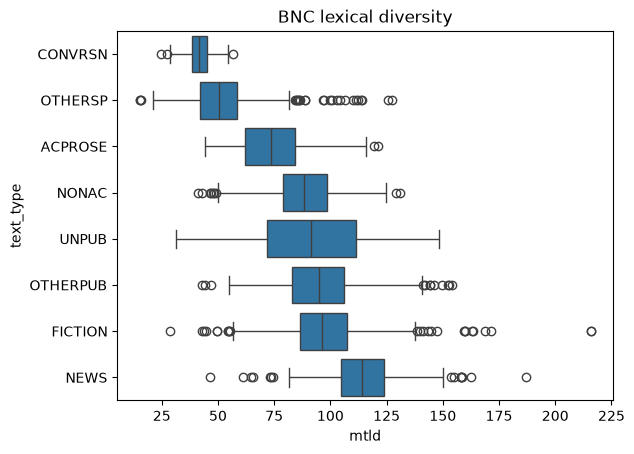

In [4]:
z = (
    msttr.with_columns(m=pl.col("mtld").mean().over("text_type"))
    .sort(by="m")
    .select(pl.exclude("m"))
)

sns.boxplot(z, x="mtld", y="text_type")
plt.title("BNC lexical diversity")
plt.show()

The differences between categories are real but small compared the variance within each. The spoken types (`CONVRSN` and `OTHERSP`) sit lowest and `NEWS` is highesthighest, but the written boxes overlap each other and the whiskers overlap for all categories. Genre influences lexical diversity, but only loosely.

### Do the measures agree?

`msttr` and `ttr500` are both measured at 500 tokens -- the first averaged over the seven or eight complete segments of a Brown text, the second taken from the opening segment alone -- so the scatter below is a picture of how much variation there is between 500-token window in a single text. The relationship is positive but with a lot of noise. This shows the benefit of averaging over multiple segments rather than trusting the first one.

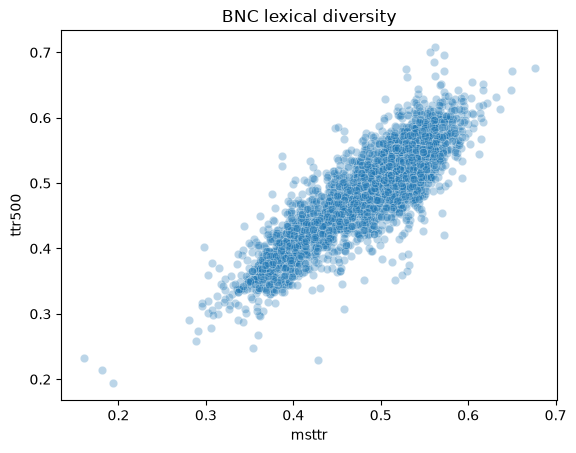

In [5]:
sns.scatterplot(z, x="msttr", y="ttr500", alpha=0.3)
plt.title("BNC lexical diversity")
plt.show()

`mtld` and `msttr` agree far more closely, but along a curve rather than a line. The top of the `msttr` range, from about 0.65 to 0.71, stretches across MTLD values from 100 to nearly 225, while the bottom of the scale compresses the range. The two order the texts almost identically; what differs is the scale.

Text(0.5, 1.0, 'BNC lexical diversity')

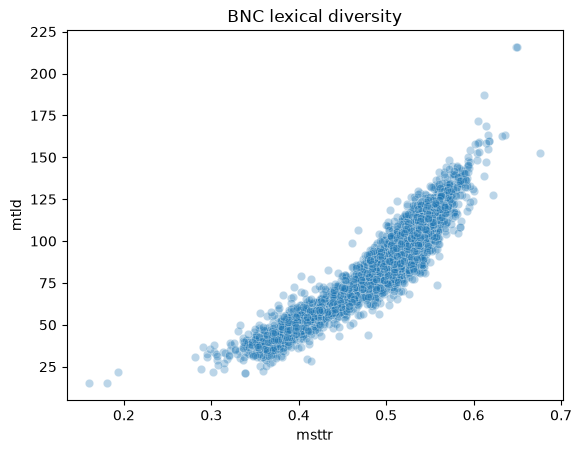

In [6]:
sns.scatterplot(z, x="msttr", y="mtld", alpha=0.3)
plt.title("BNC lexical diversity")

### What do the extremes look like? 

MSTTR scores for individual texts range from around 0.2 and around 0.7. First we'll find some texts at the extremes: 

In [7]:
msttr.filter((pl.col("msttr") < 0.2) | (pl.col("msttr") > 0.65))

file_id,text_type,ttr,ttr500,msttr,mtld
str,str,f64,f64,f64,f64
"""B1A""","""OTHERPUB""",0.59,0.68,0.68,152.61
"""G5A""","""OTHERSP""",0.03,0.19,0.19,21.89
"""HUR""","""OTHERSP""",0.03,0.23,0.16,15.30
"""HUS""","""OTHERSP""",0.03,0.21,0.18,15.20


Since the corpus is in reading order, the text can be reassembled from the `token` column: `head(250)` takes the opening, `str.join(" ")` puts the tokens back together, and `.item()` pulls the single string out of the one-row result (though we can't reverse the normalization so the punctuation and the capitals are gone).

In [8]:
(
    bnc.filter(pl.col("file_id") == "B1A")
    .select("token")
    .head(250)
    .collect()
    .get_column("token")
    .str.join(" ")
    .item()
)

"penultimate picture palace the penultimate picture palace is a cinema club all programmes are open to members only admission prices usually per programme for adults children and oaps all films are bookable in advance reserved tickets will be held until minutes before the performance when leaving the late night performances would patrons please be considerate of the residents of jeune street who may already be asleep programme is subject to change without notice mailing list is per year patrons who drive cars to the cinema are requested to park in either the union street car park or the st clement 's car park smoking is not allowed march shirley valentine people are using the words oscar and pauline collins in the same sentence she plays the eponymous heroine who leaves liverpool and her chips and egg hubby bernard hill and heads for greece where she discovers sun fun and tom conti one of the brightest bawdiest no-bull woman characters in years pauline collins is a marvel funny and tou

This text looks like some kind of movie schedule, with lots of proper names and a rich descriptive vocabulary.

And at the low end we have an auctioneer's patter, with lots of repetition and a very restricted vocabulary.

In [9]:
(
    bnc.filter(pl.col("file_id") == "G5A")
    .select("token")
    .head(250)
    .collect()
    .get_column("token")
    .str.join(" ")
    .item()
)

"under our usual conditions exhibited in we start today number one with a silver charm bracelet silver charm bracelet with the charms on it ten pounds for it the charm bracelet five pounds for it then five any advance on advance on five six seven eight nine ten gentleman up here on my right hand ten pounds any advance on ten pounds have you all finished ten pounds any advance on ten pounds number four ten pounds and number two well necklace and two rings necklace and two rings five pound for them six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty pounds twenty two twenty four any advance on twenty four gentleman twenty four pound any advance on twenty pounds twenty four pounds number four twenty four pounds lot number three watches here you have a ring watch a stone set ring watch and a ladies bracelet watch two together ten pounds for them two pounds bid any advance on two pounds four five six seven eight any advance on eight po

---

## One word class at a time

Restricting our computations to a single word class asks a narrower question: instead of how varied a text is, we ask how varied its nouns, verbs, etc. are.

First we look at nouns only:

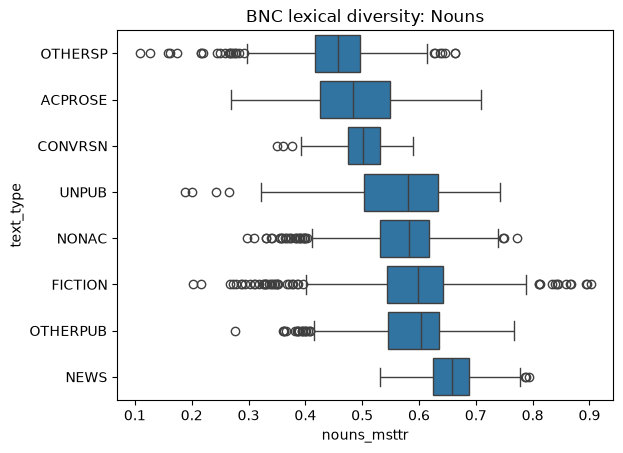

In [10]:
nouns = (
    bnc.filter(pl.col("pos") == "SUBST")
    .group_by("file_id")
    .agg(pl.col("text_type").first(), plc.msttr("token", 500).alias("nouns_msttr"))
    .with_columns(m=pl.col("nouns_msttr").mean().over("text_type"))
    .sort(by="m")
    .select(pl.exclude("m"))
    .collect(engine="streaming")
)

sns.boxplot(nouns, x="nouns_msttr", y="text_type")
plt.title("BNC lexical diversity: Nouns")
plt.show()

The same for verbs:

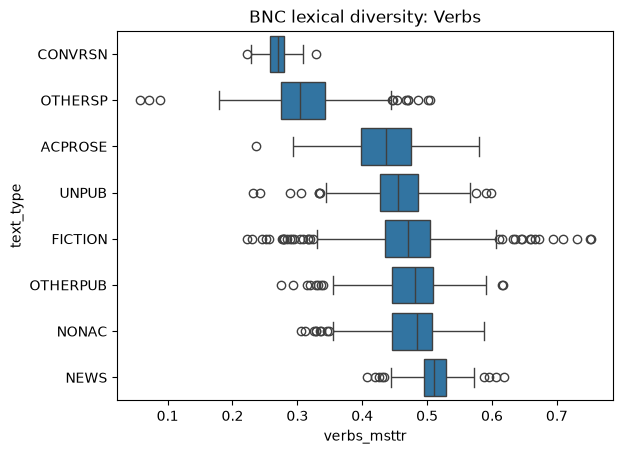

In [11]:
verbs = (
    bnc.filter(pl.col("pos") == "VERB")
    .group_by("file_id")
    .agg(pl.col("text_type").first(), plc.msttr("token", 500).alias("verbs_msttr"))
    .with_columns(m=pl.col("verbs_msttr").mean().over("text_type"))
    .sort(by="m")
    .select(pl.exclude("m"))
    .collect(engine="streaming")
)

sns.boxplot(verbs, x="verbs_msttr", y="text_type")
plt.title("BNC lexical diversity: Verbs")
plt.show()

The join operation puts the three MSTTR columns side by side in a single DataFrame. Seaborn takes Polars frames directly for most of its plots, but `pairplot` still needs `.to_pandas()`. Since so far we've seen written and spoken texts don't nessarily pattern the same, we can use color to highlight the differences.

Overall, the MSTTR for verbs and nouns track each other fairly closely. But, the difference in MSTTR between spoken and written texts is much large for verbs than for nouns. That is, the diversity of nouns used in speech is similar to the diversity in writing, but the diversity in verbs is much lower.

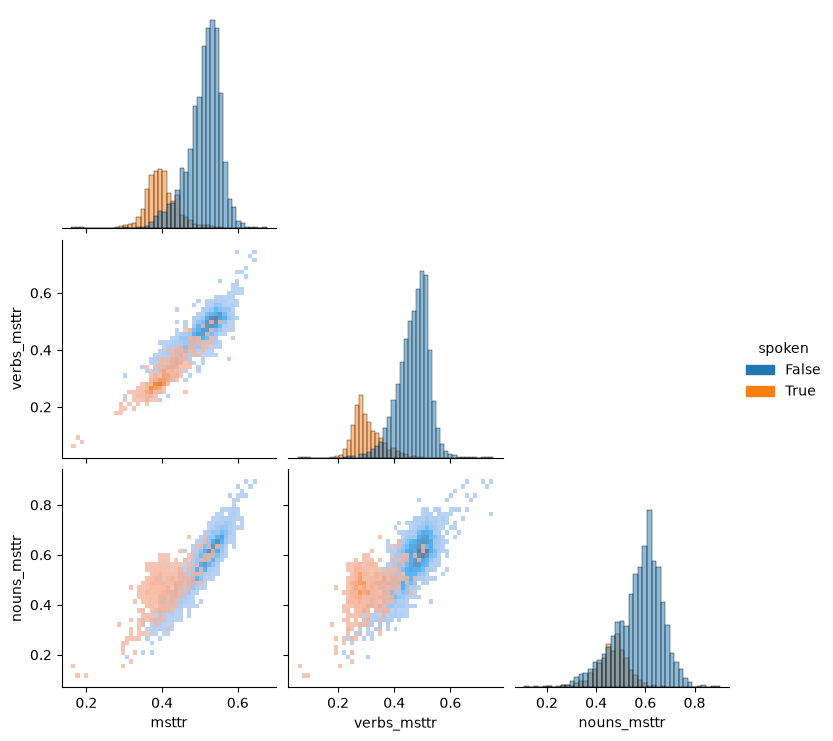

In [12]:
combined = msttr.join(nouns, on=["file_id", "text_type"]).join(
    verbs, on=["file_id", "text_type"]
)

sns.pairplot(
    data=combined.select(
        "msttr",
        "verbs_msttr",
        "nouns_msttr",
        pl.col("text_type").is_in(["CONVRSN", "OTHERSP"]).alias("spoken"),
    ).to_pandas(),
    hue="spoken",
    kind="hist",
    corner=True,
    plot_kws={"alpha": 0.8},
)
plt.show()

---

## Vocabulary growth

Every measure so far reduces a text to a single number by accounting for, somehow, the text length. A growth curve does the opposite: it plots vocabulary against length directly and leaves the reading to the eye. That needs texts long enough to have a shape, so the corpus changes here to five books from the Gutenberg collection, one file each, running from a collection of children's stories to a novel several times its length.

Putting `.select("token", "file_id")` before the filter means the scan reads two columns and no more, and the `is_in` predicate pushes down into it, so only the five books are ever read from disk.

In [13]:
subset = [
    "austen-emma.txt",
    "chesterton-ball.txt",
    "edgeworth-parents.txt",
    "melville-moby_dick.txt",
    "bryant-stories.txt",
]

books = (
    plc.from_nltk(nltk.corpus.gutenberg)
    .filter(pl.col("file_id").is_in(subset))
    .select("token", "file_id")
    .filter(pl.col("file_id").is_in(subset), plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
)

MTLD ranks the five from `bryant-stories.txt` at 55.816 up to `melville-moby_dick.txt` at 105.638, and the bar chart that follows plots the same five numbers. These books differ in length by a factor of several, which is the comparison a raw type-token ratio cannot make: the gap between the `ttr` and `ttr250` columns in the Brown table above is what a whole-text ratio would do to a ranking like this one.

In [14]:
mtld = books.group_by("file_id").agg(plc.mtld("token").alias("mtld")).sort(by="mtld")
mtld

file_id,mtld
str,f64
"""bryant-stories.txt""",55.82
"""edgeworth-parents.txt""",77.04
"""chesterton-ball.txt""",79.96
"""austen-emma.txt""",91.23
"""melville-moby_dick.txt""",105.64


<Axes: xlabel='mtld', ylabel='file_id'>

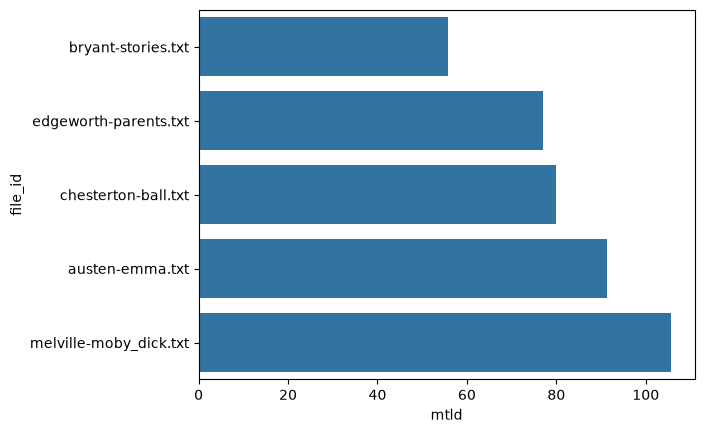

In [15]:
sns.barplot(mtld, y="file_id", x="mtld")

`vocabulary_growth` is the one measure here that returns a column rather than a scalar: one value per token, the number of distinct types seen up to that point, so the last row is the text's type count. Its implementation is plain Polars underneath -- `is_first_distinct().cum_sum()` -- and `with_row_index` supplies the token position to plot it against.

The curve for *Emma* climbs steeply and then bends, but it never flattens. At 160,000 tokens the novel is still introducing words it has not used before, and the total would have been higher had Austen written another chapter. This is the sense in which a text does not have a vocabulary size, only a vocabulary size at a given length.

Text(0.5, 1.0, 'Vocabulary growth curve: Emma')

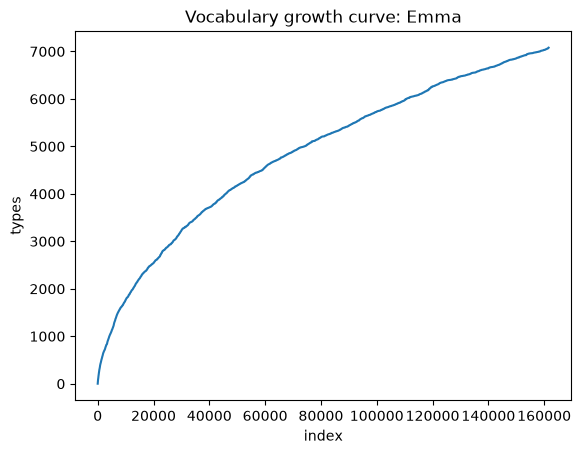

In [16]:
vgc = (
    books.filter(pl.col("file_id") == "austen-emma.txt")
    .with_columns(plc.vocabulary_growth("token").alias("types"))
    .with_row_index()
)

sns.lineplot(vgc, x="index", y="types")
plt.title("Vocabulary growth curve: Emma")

All five at once. `.over("file_id")` computes the running count within each book and writes it back to the rows it came from, and `pl.row_index().over("file_id")` restarts the position count at each book so the curves begin together at the origin instead of running end to end.

`chesterton-ball.txt` climbs the steepest of the five and stops at around 80,000 tokens, well above both *Emma* and `edgeworth-parents.txt` at that point, although MTLD ranked it between the two of them. Comparing texts at their endpoints compares them at different values of $N$. Observing the curves allows a comparison at the same $N$.

Text(0.5, 1.0, 'Vocabulary growth curves')

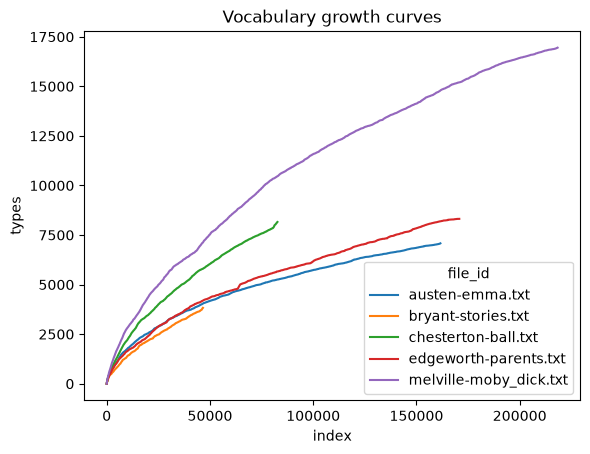

In [17]:
vgc = books.with_columns(
    plc.vocabulary_growth("token").alias("types").over("file_id"),
    pl.row_index().over("file_id").alias("index"),
)

sns.lineplot(vgc, x="index", y="types", hue="file_id")
plt.title("Vocabulary growth curves")

## The frequency spectrum

Underneath all of these measures is a single distribution: how many types occur once, how many twice, and so on. `frequency_spectrum` returns it as a struct with fields `m`, the frequency class, and `V(m,N)`, the number of types in that class. We use `unnest` to separate this into two columns.

`plc.proportion` divides each class by the total number of types and `cum_sum` accumulates them. Because the result is assigned back through `with_columns` without an alias, it replaces `V(m,N)` in place: the column keeps its name while the values become a cumulative share running to 1.

Text(0.5, 1.0, 'Cumulative frequency spectrum: Moby Dick')

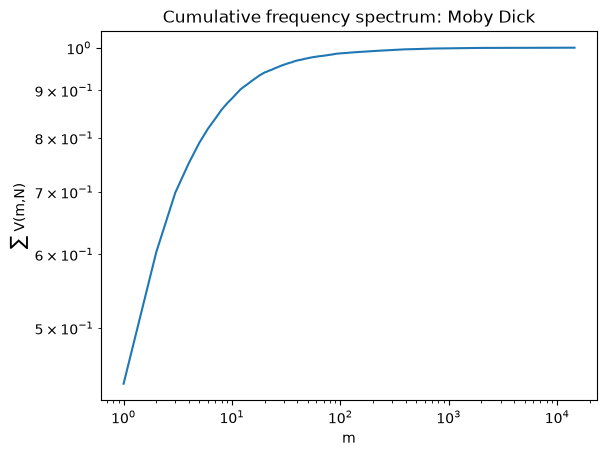

In [18]:
mb_spectrum = (
    books.filter(pl.col("file_id") == "melville-moby_dick.txt")
    .select(plc.frequency_spectrum("token", sort=True))
    .unnest()
    .with_columns(plc.proportion(pl.col("V(m,N)")).cum_sum())
)

sns.lineplot(mb_spectrum, x="m", y="V(m,N)")
plt.loglog()
plt.ylabel(r"$\sum$ V(m,N)")
plt.title("Cumulative frequency spectrum: Moby Dick")

The curve starts just under 0.45, so something over four types in ten in *Moby-Dick* occur exactly once. It is past 0.9 well before $m = 100$, and the flat stretch running out beyond $m = 10^4$ is the handful of function words that carry most of the tokens. Both axes are logarithmic because the frequency classes span four orders of magnitude while nearly all the types sit in the first few.

Overlaying the spectrum of a second book, `austen-emma.txt`, puts the two shapes together. *Moby-Dick* starts higher and stays above it through the low classes -- a larger share of its vocabulary appears once or twice -- and the two converge only in the tail.

Text(0.5, 1.0, 'Cumulative frequency spectrum')

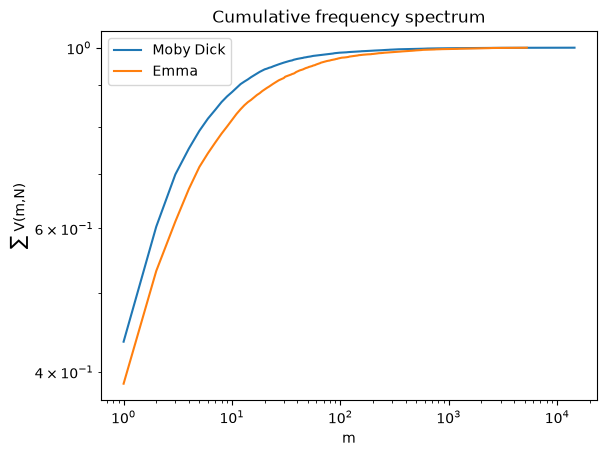

In [19]:
e_spectrum = (
    books.filter(pl.col("file_id") == "austen-emma.txt")
    .select(plc.frequency_spectrum("token", sort=True))
    .unnest()
    .with_columns(plc.proportion(pl.col("V(m,N)")).cum_sum())
)

sns.lineplot(mb_spectrum, x="m", y="V(m,N)", label="Moby Dick")
sns.lineplot(e_spectrum, x="m", y="V(m,N)", label="Emma")
plt.ylabel(r"$\sum$ V(m,N)")
plt.loglog()
plt.title("Cumulative frequency spectrum")